In [108]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from packaging import *
import xarray as xr
import numpy as np
from scipy.ndimage import gaussian_filter

In [110]:
# sanandaj : 35°18′41″N 46°59′46″E

In [112]:
def map():
    plt.figure(figsize=(20,20))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines(resolution='50m', color='k')
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.OCEAN, color='cyan')
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()])
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      xlocs=np.arange(-180, 181, 5), ylocs=np.arange(-90, 91, 5),
                      color='gray', alpha=0.3)
    ax.plot(46+59/60+46/3600, 35+18/60+41/3600, 'ro', markersize=5)
    return ax

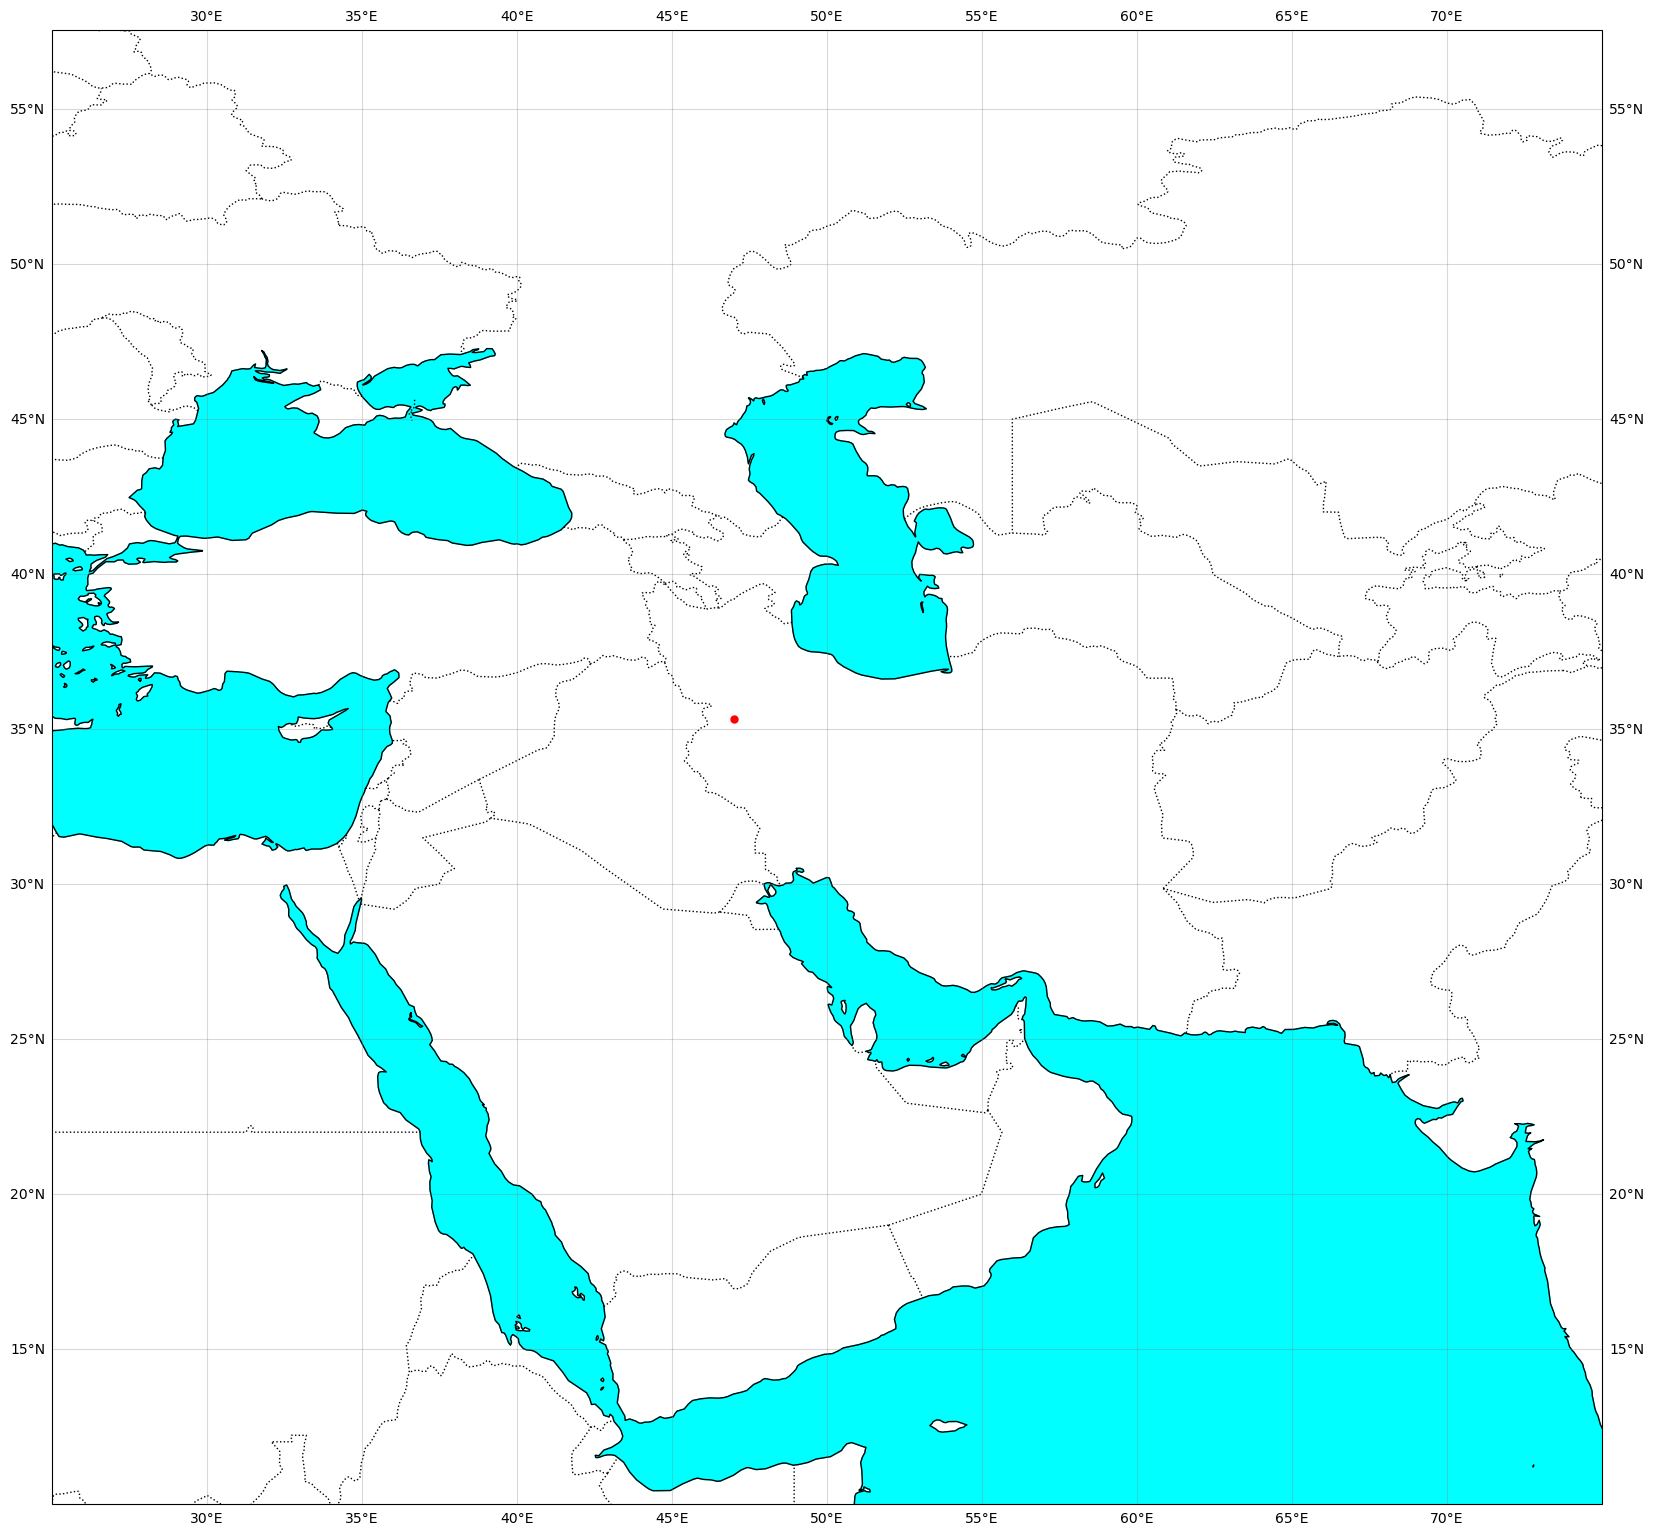

In [130]:
ds1 = xr.open_dataset("pl20031208.nc")
ds2 = xr.open_dataset("sf20031208.nc")
ds3 = xr.open_dataset("tp20031208.nc")

geo = ds1['z']
temp = ds1['t']
temp_celsius = temp - 273.15
u_wind = ds1['u']
v_wind = ds1['v']

u10 = ds2['u10']
v10 = ds2['v10']
t2m = ds2['t2m']
t2m_celsius = t2m - 273.15
mslp = ds2['msl']

precip = ds3['tp']
precip_mm = precip * 1000

lon = ds1['longitude']
lat = ds1['latitude']
ax = map()
#plt.savefig('Empty')
plt.show()

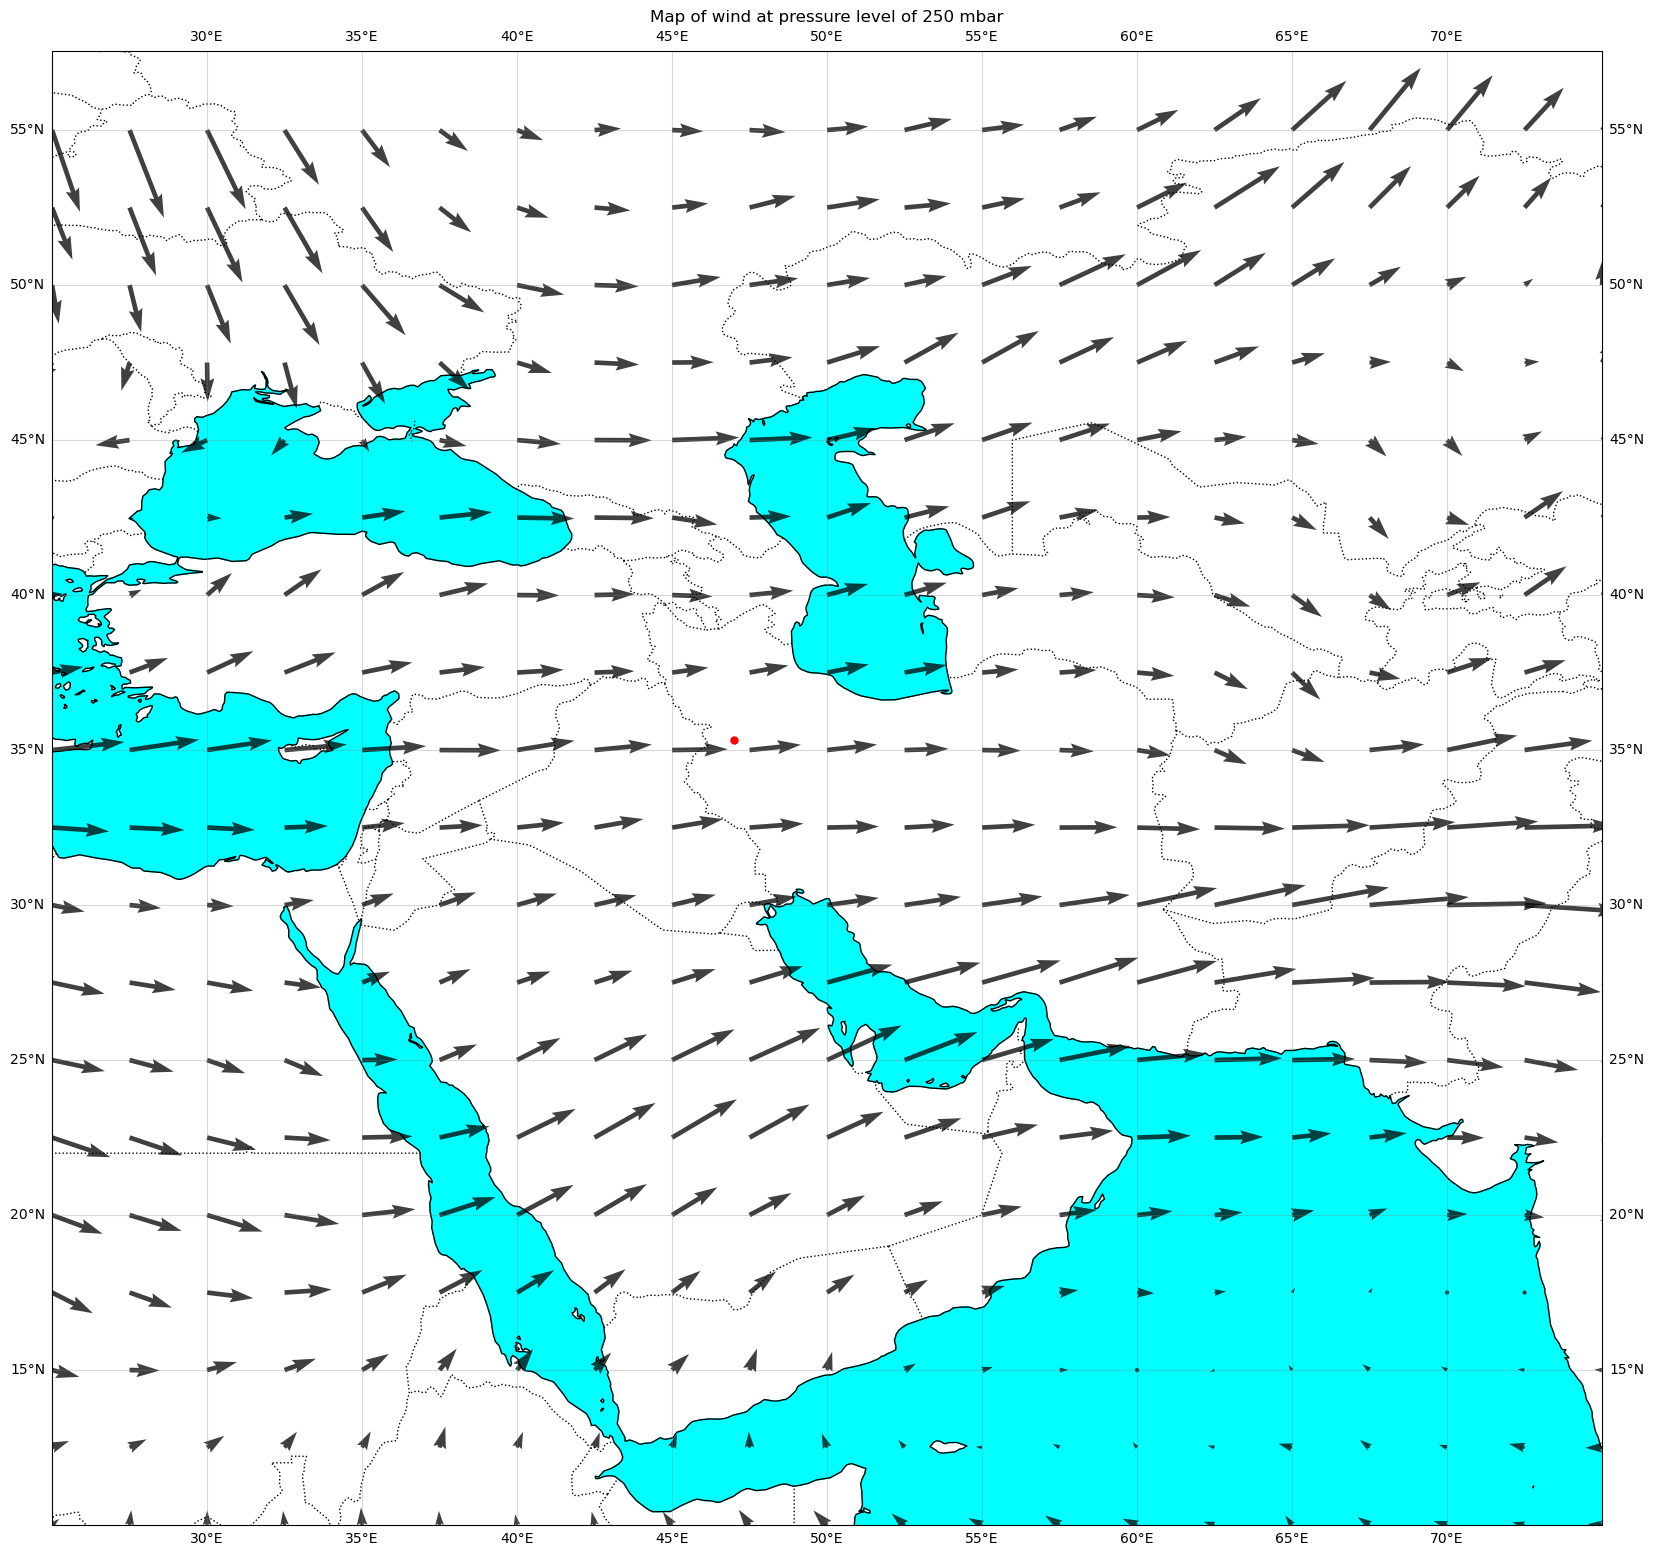

In [132]:
#1 
def plot_wind_250():
    u_250 = u_wind.sel(pressure_level=250).squeeze()[::10,::10]
    v_250 = v_wind.sel(pressure_level=250).squeeze()[::10,::10]
    lon1 = lon[::10]
    lat1 = lat[::10]
    ax = map()
    ax.quiver(lon1,lat1,u_250,v_250,alpha=0.75)
    plt.title('Map of wind at pressure level of 250 mbar')
    #plt.savefig('Map of wind at pressure level of 250 mbar')

plot_wind_250()

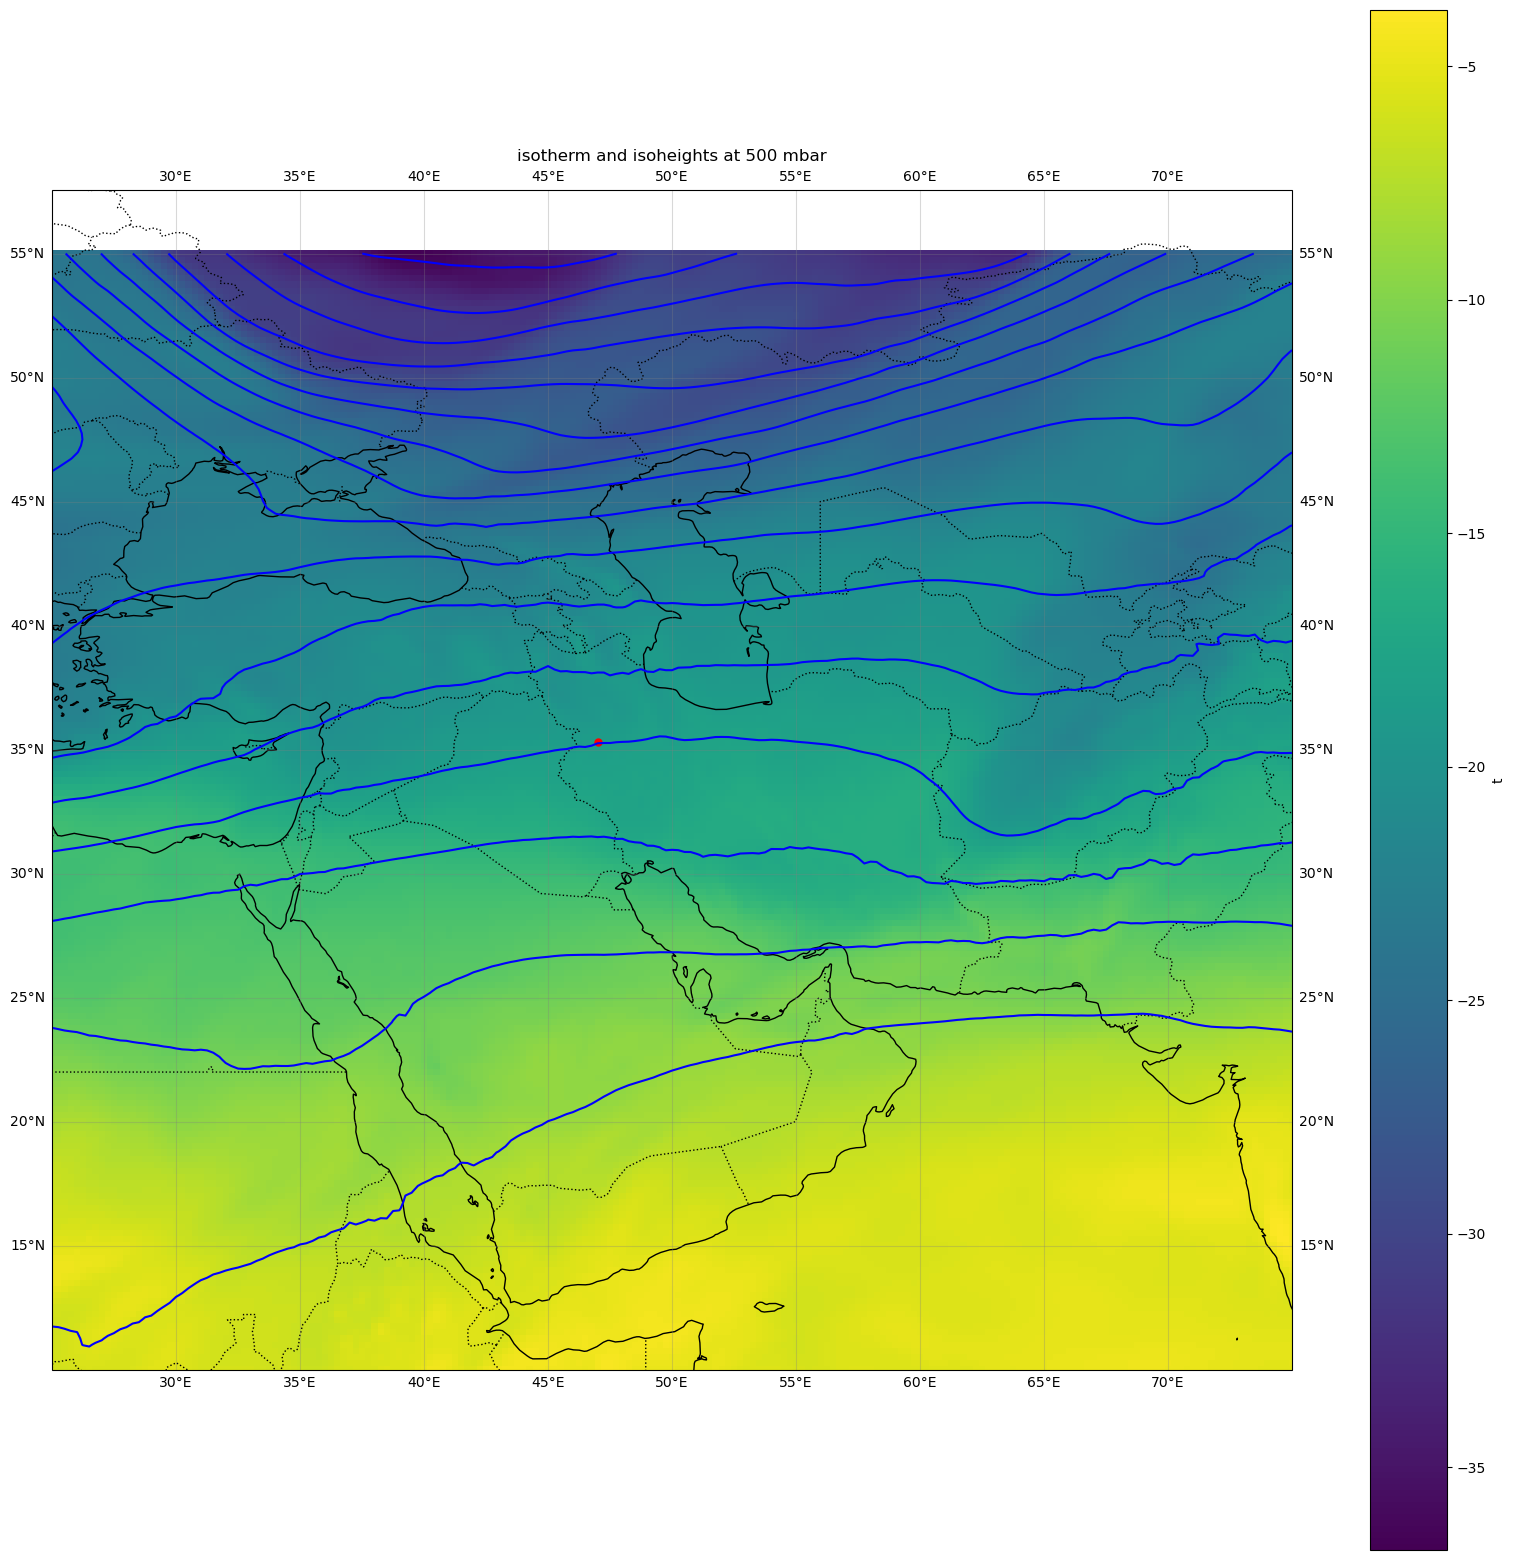

In [134]:
#2

def plot_temp_geo_500():
    temp_500_celsius = temp_celsius.sel(pressure_level=500)
    geo_500 = geo.sel(pressure_level=500)
    geo_500_2d = geo_500.squeeze()
    ax = map()
    geo_500_2d.plot.contour(ax=ax, transform=ccrs.PlateCarree(), colors='Blue',levels = 20)
    temp_500_celsius.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='viridis')
    plt.title('Isotherm and isoheights at 500 mbar')
    #plt.savefig('isotherm and isoheights at 500 mbar')

plot_temp_geo_500()

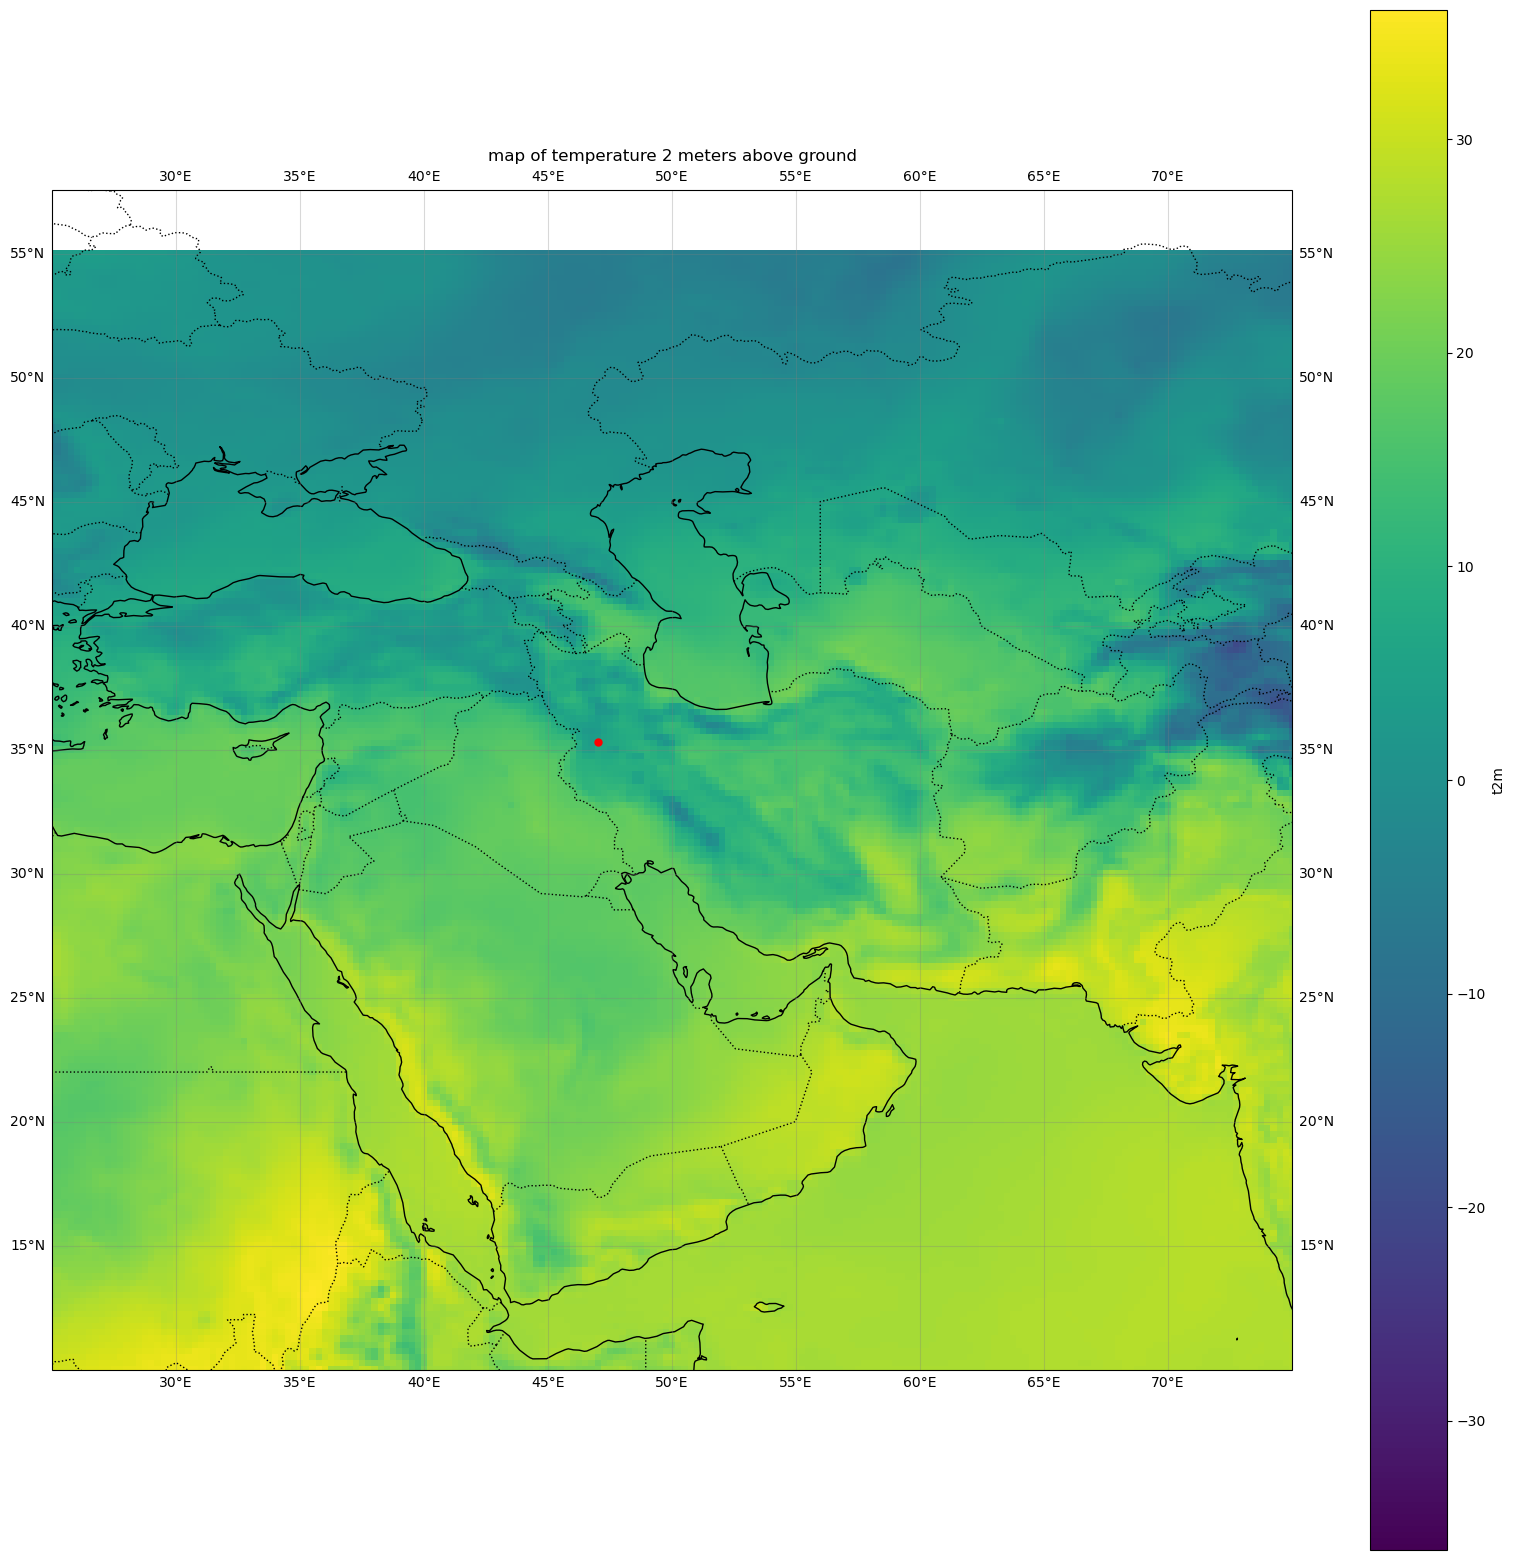

In [140]:
#3

def plot_t2m(cmap='viridis'):
    ax = map()
    t2m_celsius.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap)
    plt.title('Map of temperature 2 meters above ground')
    #plt.savefig('map of temperature 2 meters above ground')
plot_t2m()

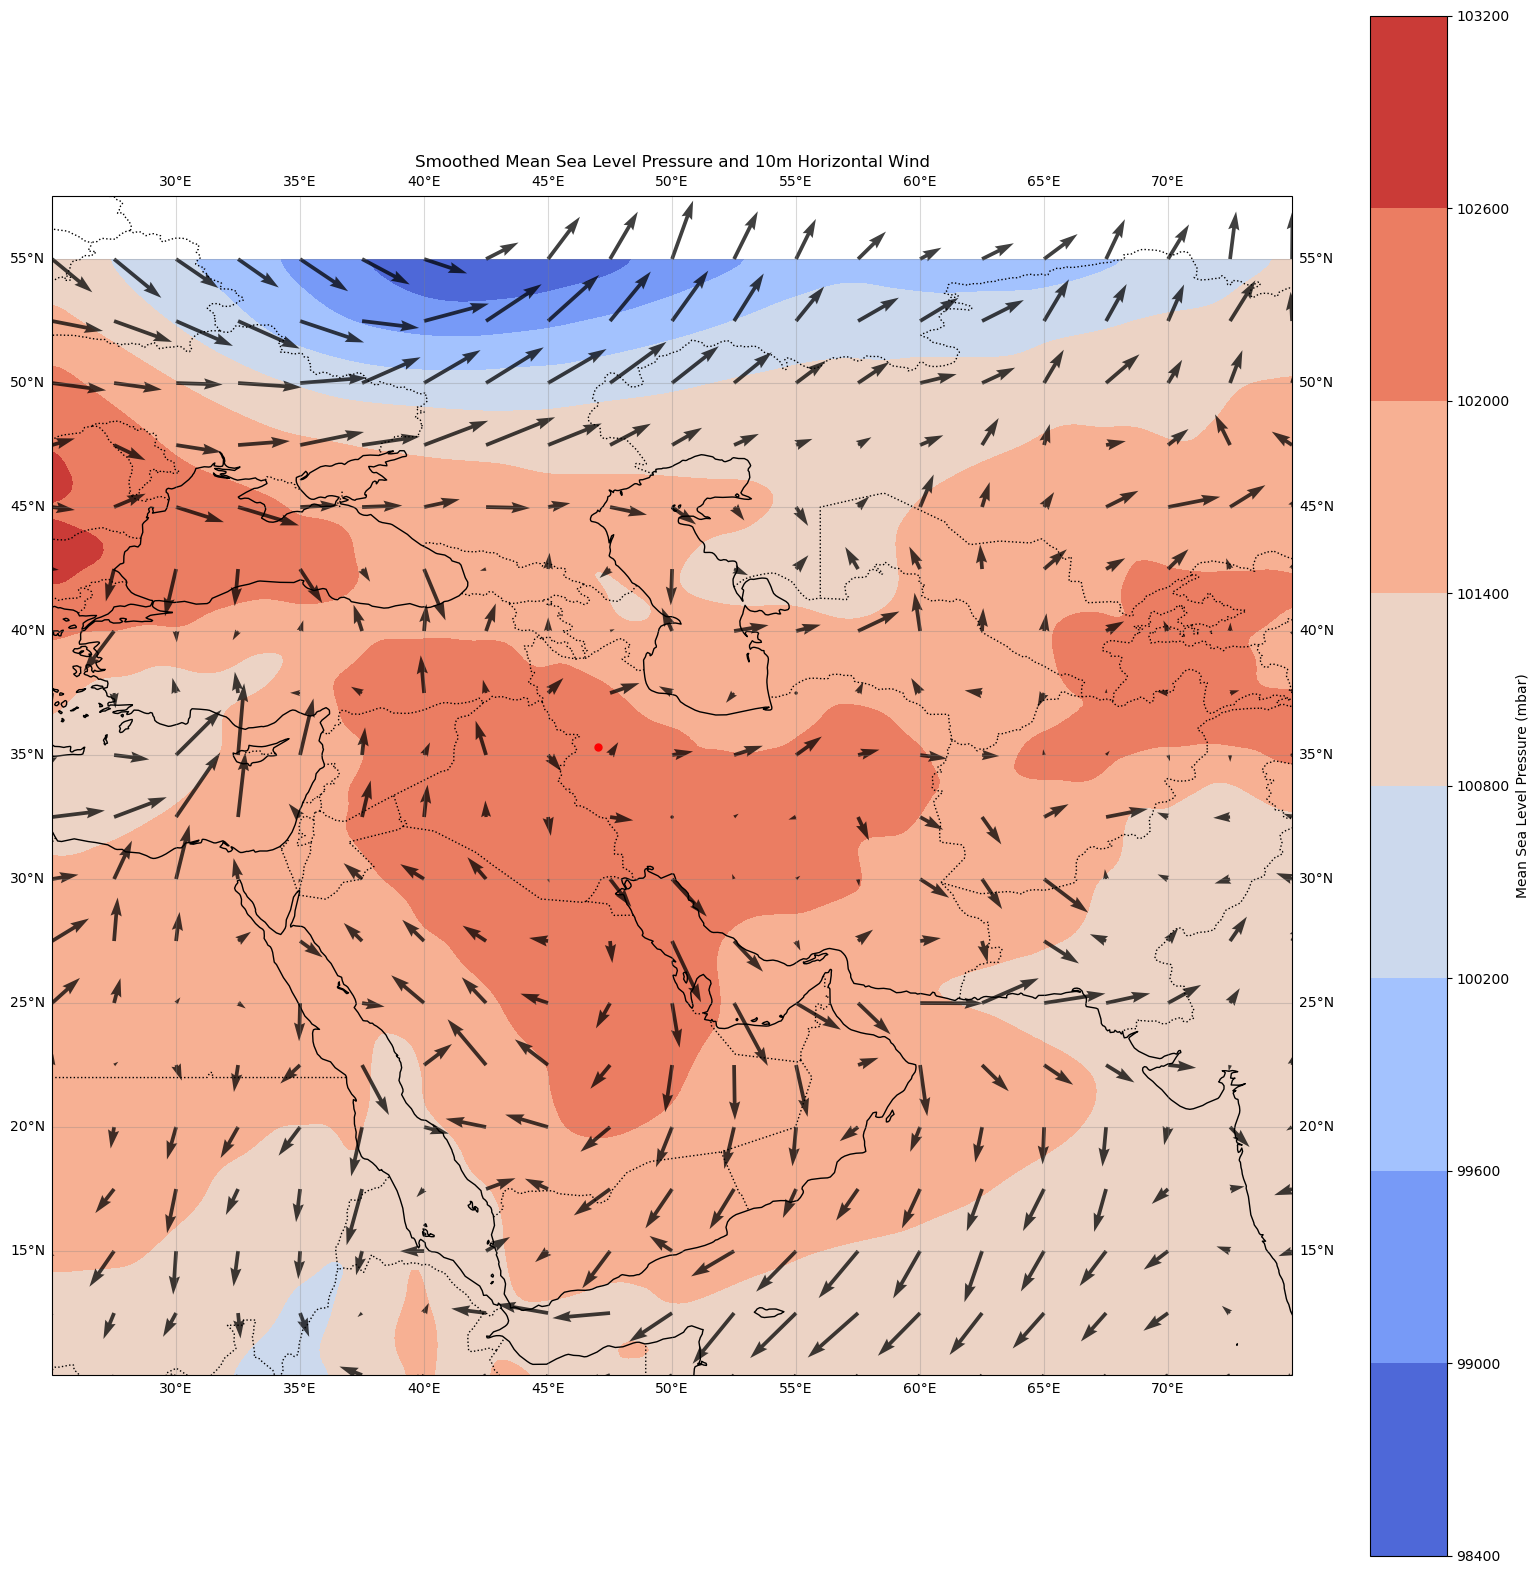

In [142]:
#4

def plot_wind_10_mslp():
    ax = map()
    u_10 = u10.squeeze()[::10,::10]
    v_10 = v10.squeeze()[::10,::10]
    mslp_smooth = gaussian_filter(mslp[0,:,:], sigma=2)
    p = ax.contourf(lon, lat, mslp_smooth, cmap='coolwarm', transform=ccrs.PlateCarree())
    cb = plt.colorbar(p, ax=ax, orientation='vertical', label='Mean Sea Level Pressure (mbar)')
    lon1 = lon[::10]
    lat1 = lat[::10]
    ax.quiver(lon1,lat1,u_10,v_10,alpha=0.75)
    plt.title('Smoothed Mean Sea Level Pressure and 10m Horizontal Wind')
    #plt.savefig('Smoothed Mean Sea Level Pressure and 10m Horizontal Wind')

plot_wind_10_mslp()

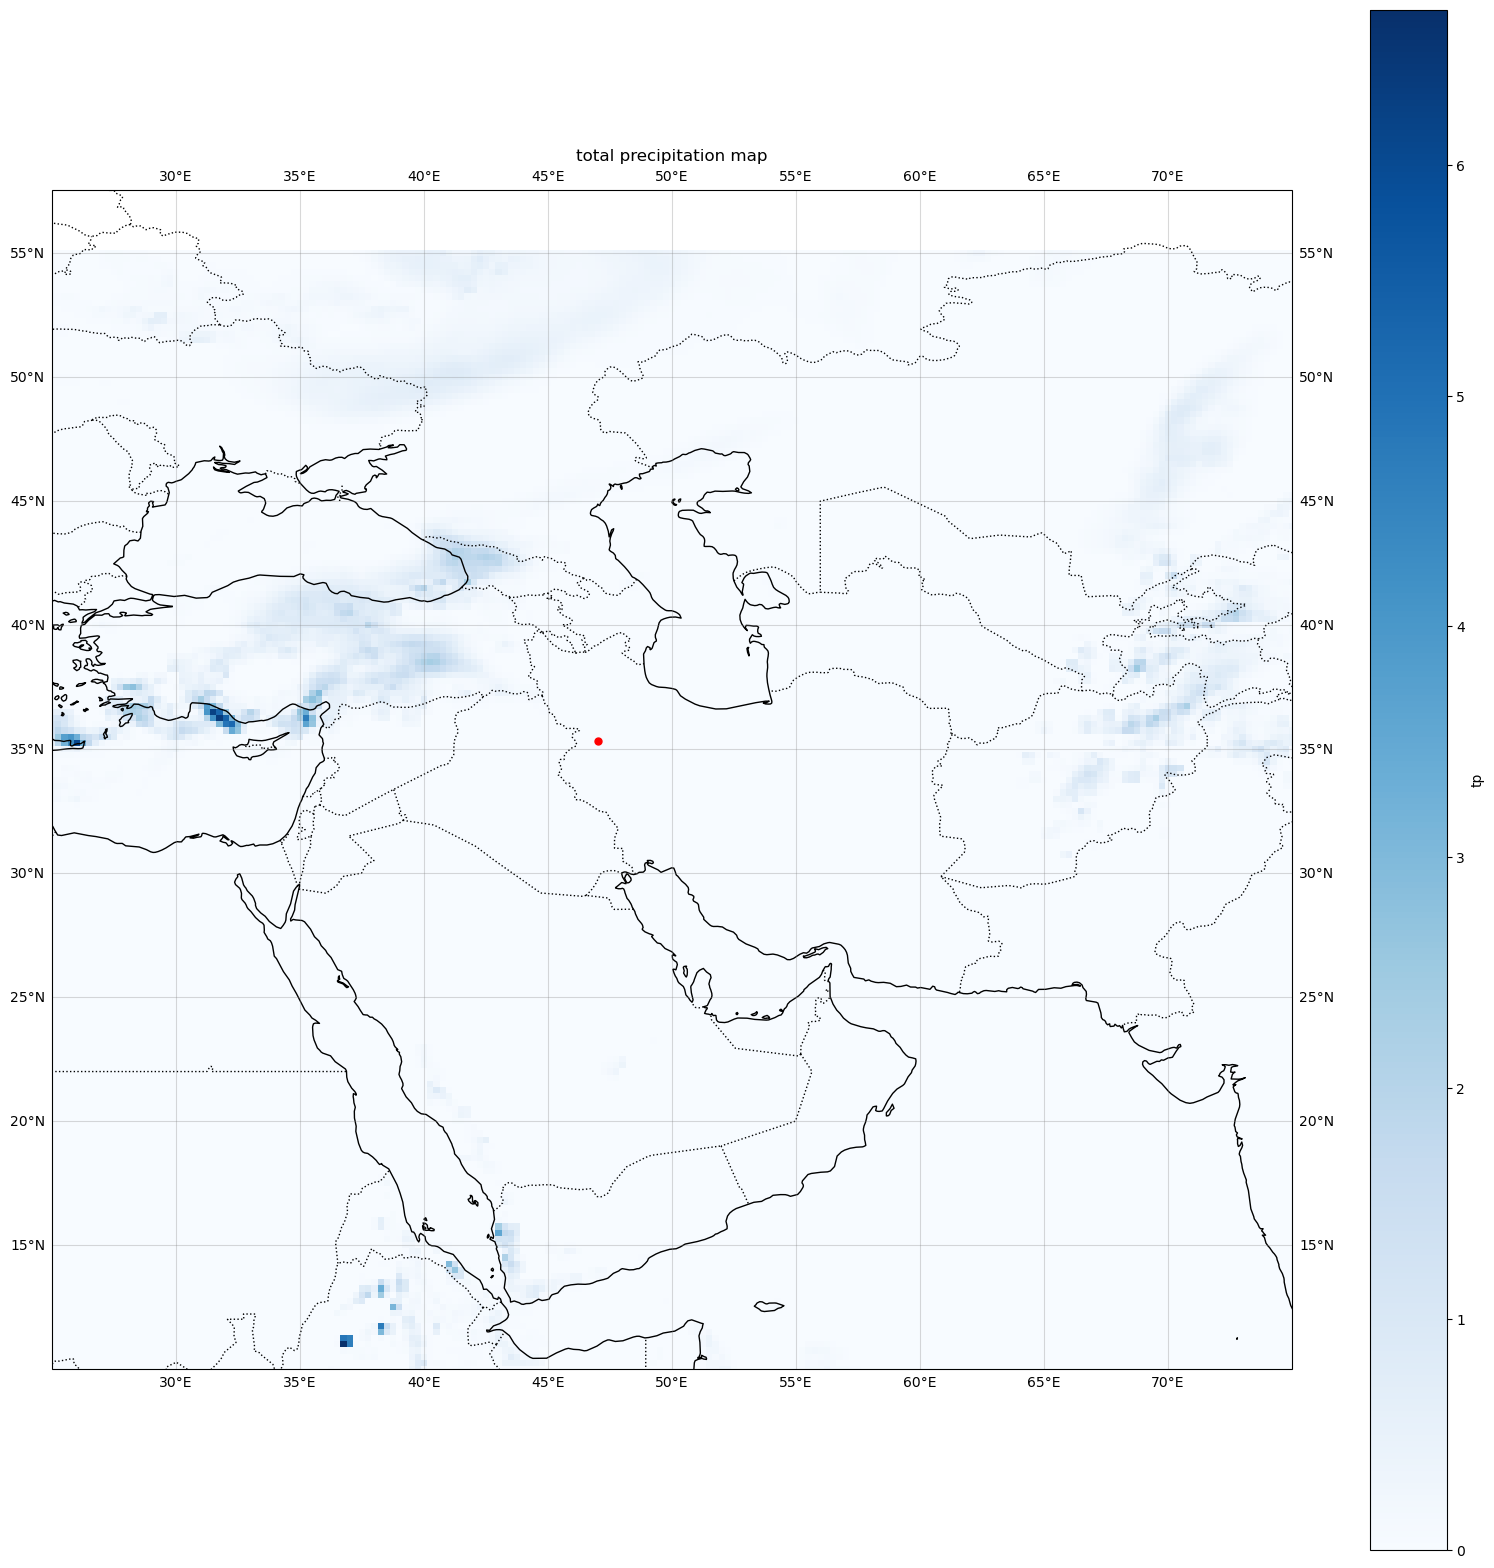

In [144]:
#5

def plot_precip(cmap='Blues'):
    ax = map()
    precip_mm.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap)
    plt.title('Total precipitation map')
    #plt.savefig('total precipitation map')
    

plot_precip()